<a href="https://colab.research.google.com/github/S4niya/P/blob/main/SMLD_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving HeartDiseaseTrain-Test (1) (1).csv to HeartDiseaseTrain-Test (1) (1).csv


In [3]:
import pandas as pd

df = pd.read_csv("heart.csv")

print(df.head())
print(df.columns)
print(df.shape)

   age     sex chest_pain_type  resting_blood_pressure  cholestoral  \
0   52    Male  Typical angina                     125          212   
1   53    Male  Typical angina                     140          203   
2   70    Male  Typical angina                     145          174   
3   61    Male  Typical angina                     148          203   
4   62  Female  Typical angina                     138          294   

      fasting_blood_sugar               rest_ecg  Max_heart_rate  \
0    Lower than 120 mg/ml  ST-T wave abnormality             168   
1  Greater than 120 mg/ml                 Normal             155   
2    Lower than 120 mg/ml  ST-T wave abnormality             125   
3    Lower than 120 mg/ml  ST-T wave abnormality             161   
4  Greater than 120 mg/ml  ST-T wave abnormality             106   

  exercise_induced_angina  oldpeak        slope vessels_colored_by_flourosopy  \
0                      No      1.0  Downsloping                           Two   
1 

In [4]:
print(df.columns.tolist())

['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholestoral', 'fasting_blood_sugar', 'rest_ecg', 'Max_heart_rate', 'exercise_induced_angina', 'oldpeak', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia', 'target']


In [5]:
# Check data types
print("Data Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

Data Types:
age                                int64
sex                               object
chest_pain_type                   object
resting_blood_pressure             int64
cholestoral                        int64
fasting_blood_sugar               object
rest_ecg                          object
Max_heart_rate                     int64
exercise_induced_angina           object
oldpeak                          float64
slope                             object
vessels_colored_by_flourosopy     object
thalassemia                       object
target                             int64
dtype: object

Missing Values:
age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            

In [6]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (302, 14)


In [7]:
# Separate input features and target

X = df.drop("target", axis=1)
y = df["target"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nTarget Values:")
print(y.value_counts())

Features:
['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholestoral', 'fasting_blood_sugar', 'rest_ecg', 'Max_heart_rate', 'exercise_induced_angina', 'oldpeak', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia']

Target:
target

Target Values:
target
1    164
0    138
Name: count, dtype: int64


In [8]:
# Convert categorical columns into numerical columns
X = pd.get_dummies(X, drop_first=True)

print("Features after encoding:")
print(X.columns.tolist())

print("\nNew shape:", X.shape)

Features after encoding:
['age', 'resting_blood_pressure', 'cholestoral', 'Max_heart_rate', 'oldpeak', 'sex_Male', 'chest_pain_type_Atypical angina', 'chest_pain_type_Non-anginal pain', 'chest_pain_type_Typical angina', 'fasting_blood_sugar_Lower than 120 mg/ml', 'rest_ecg_Normal', 'rest_ecg_ST-T wave abnormality', 'exercise_induced_angina_Yes', 'slope_Flat', 'slope_Upsloping', 'vessels_colored_by_flourosopy_One', 'vessels_colored_by_flourosopy_Three', 'vessels_colored_by_flourosopy_Two', 'vessels_colored_by_flourosopy_Zero', 'thalassemia_No', 'thalassemia_Normal', 'thalassemia_Reversable Defect']

New shape: (302, 22)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (241, 22)
Testing data: (61, 22)


In [10]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 8 features
selector = SelectKBest(
    score_func=f_classif,
    k=8
)

# Fit feature selection only on training data
X_train_selected = selector.fit_transform(X_train, y_train)

# Apply the same selection to test data
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()]

print("Selected Features:")
for feature in selected_features:
    print(feature)

Selected Features:
Max_heart_rate
oldpeak
chest_pain_type_Non-anginal pain
chest_pain_type_Typical angina
exercise_induced_angina_Yes
slope_Flat
vessels_colored_by_flourosopy_Zero
thalassemia_Reversable Defect


In [11]:
feature_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "Score": selector.scores_
})

feature_scores = feature_scores.sort_values(
    by="Score",
    ascending=False
)

print(feature_scores)

                                     Feature       Score
8             chest_pain_type_Typical angina  112.581366
21             thalassemia_Reversable Defect   78.145356
12               exercise_induced_angina_Yes   63.264946
18        vessels_colored_by_flourosopy_Zero   62.208187
3                             Max_heart_rate   55.236089
4                                    oldpeak   45.811505
7           chest_pain_type_Non-anginal pain   35.930817
13                                slope_Flat   27.680618
5                                   sex_Male   22.882149
17         vessels_colored_by_flourosopy_Two   17.340119
16       vessels_colored_by_flourosopy_Three   12.926617
6            chest_pain_type_Atypical angina   12.352745
15         vessels_colored_by_flourosopy_One   10.928052
11            rest_ecg_ST-T wave abnormality    7.148255
0                                        age    6.858230
10                           rest_ecg_Normal    5.572960
2                              

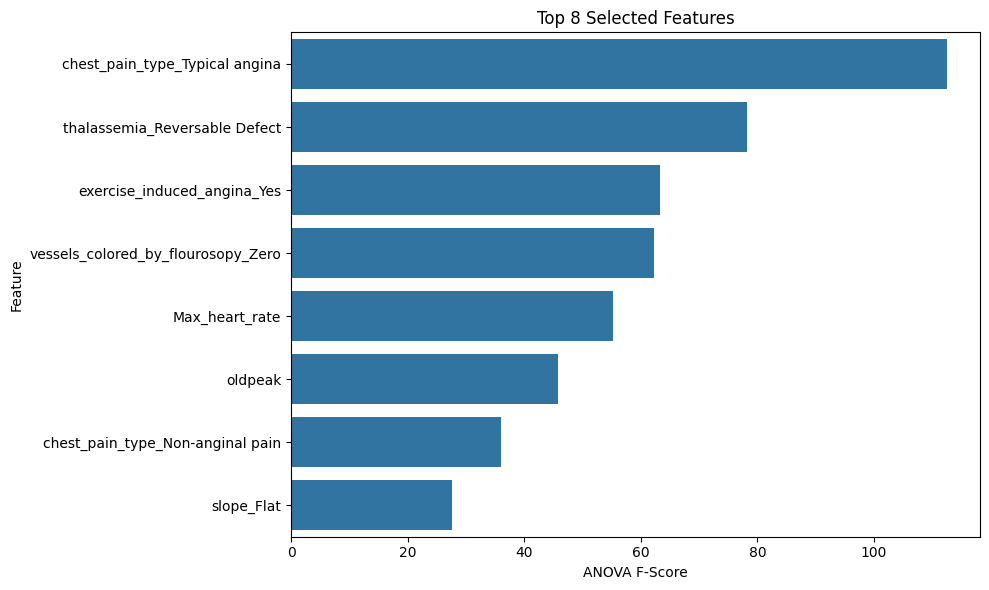

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = feature_scores.head(8)

plt.figure(figsize=(10, 6))

sns.barplot(
    x="Score",
    y="Feature",
    data=top_features
)

plt.title("Top 8 Selected Features")
plt.xlabel("ANOVA F-Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print("Feature scaling completed!")

Feature scaling completed!


In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [15]:
y_pred = model.predict(X_test_scaled)

print("Predictions completed!")
print("\nPredicted values:")
print(y_pred)

Predictions completed!

Predicted values:
[0 1 0 1 1 0 1 0 1 0 1 1 0 1 0 1 1 0 1 1 0 0 1 0 1 0 0 0 0 1 0 1 1 1 0 1 0
 1 1 1 1 1 1 1 0 0 1 0 1 0 0 1 1 0 1 1 0 1 0 0 0]


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("================================")
print("LOGISTIC REGRESSION PERFORMANCE")
print("================================")

print("Accuracy  :", round(accuracy * 100, 2), "%")
print("Precision :", round(precision * 100, 2), "%")
print("Recall    :", round(recall * 100, 2), "%")
print("F1 Score  :", round(f1 * 100, 2), "%")

LOGISTIC REGRESSION PERFORMANCE
Accuracy  : 83.61 %
Precision : 84.85 %
Recall    : 84.85 %
F1 Score  : 84.85 %


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        28
           1       0.85      0.85      0.85        33

    accuracy                           0.84        61
   macro avg       0.83      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



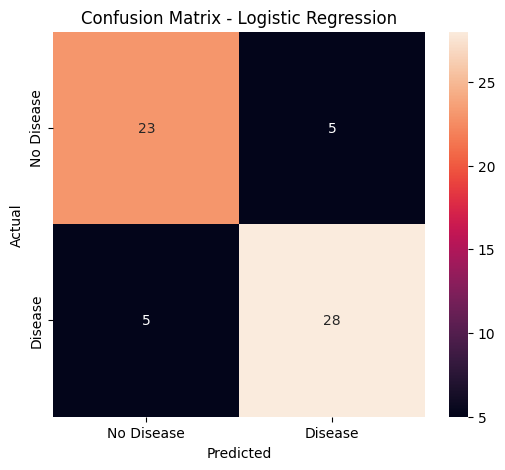

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
# ============================================
# DISEASE RISK PREDICTION
# ============================================

# Take one patient from the test dataset
sample_patient = X_test.iloc[[0]]

# Select the same 8 features
sample_selected = selector.transform(sample_patient)

# Standardize the features
sample_scaled = scaler.transform(sample_selected)

# Make prediction
prediction = model.predict(sample_scaled)

# Get probability
probability = model.predict_proba(sample_scaled)[0][1]

print("======================================")
print("      HEART DISEASE RISK PREDICTION")
print("======================================")

if prediction[0] == 1:
    print("Prediction: HIGH RISK OF HEART DISEASE")
else:
    print("Prediction: LOW RISK OF HEART DISEASE")

print("Disease Risk Probability:",
      round(probability * 100, 2), "%")

      HEART DISEASE RISK PREDICTION
Prediction: LOW RISK OF HEART DISEASE
Disease Risk Probability: 11.93 %


In [20]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

coefficients = model.coef_[0]

importance = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": coefficients
})

importance["Absolute Importance"] = abs(
    importance["Coefficient"]
)

importance = importance.sort_values(
    by="Absolute Importance",
    ascending=False
)

print("Feature Importance:")
print(importance[["Feature", "Coefficient"]])

Feature Importance:
                              Feature  Coefficient
6  vessels_colored_by_flourosopy_Zero     1.063132
7       thalassemia_Reversable Defect    -0.799495
3      chest_pain_type_Typical angina    -0.712742
1                             oldpeak    -0.493796
0                      Max_heart_rate     0.447303
4         exercise_induced_angina_Yes    -0.412672
2    chest_pain_type_Non-anginal pain     0.373968
5                          slope_Flat    -0.336054


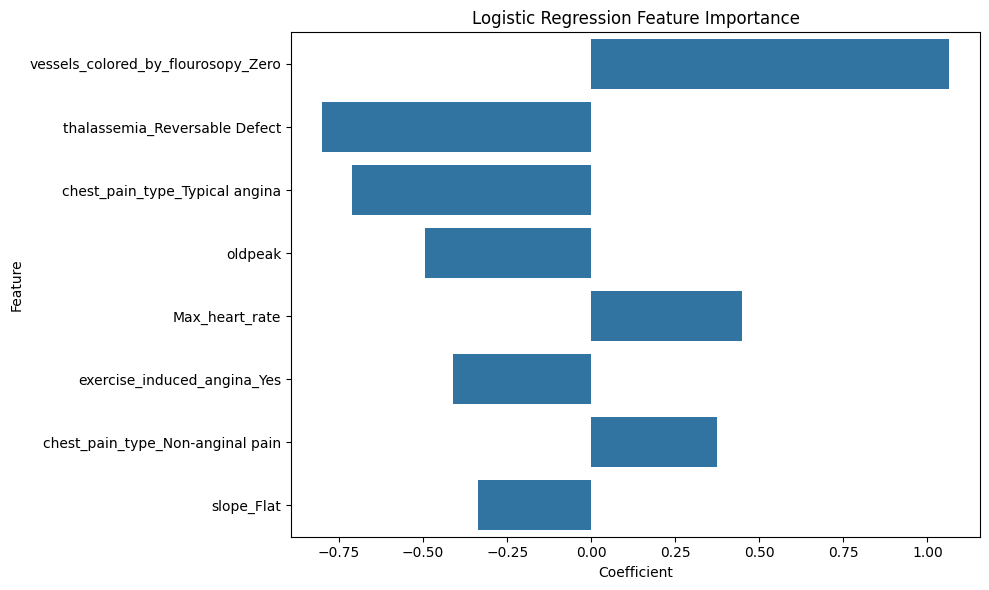

In [21]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=importance
)

plt.title("Logistic Regression Feature Importance")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [22]:
# ============================================
# INTERACTIVE HEART DISEASE RISK PREDICTION
# ============================================

print("Enter Patient Details")
print("----------------------")

# 1. Max Heart Rate
max_heart_rate = float(input("Maximum Heart Rate: "))

# 2. Oldpeak
oldpeak = float(input("Oldpeak: "))

# 3. Chest Pain Type
print("\nChest Pain Type:")
print("1 - Typical angina")
print("2 - Non-anginal pain")
print("3 - Atypical angina")
print("4 - Asymptomatic")

chest_pain = int(input("Enter choice (1-4): "))

# 4. Exercise Induced Angina
print("\nExercise Induced Angina:")
print("1 - Yes")
print("0 - No")

exercise_angina = int(input("Enter choice (0/1): "))

# 5. Slope
print("\nSlope:")
print("1 - Flat")
print("2 - Upsloping")
print("3 - Downsloping")

slope = int(input("Enter choice (1-3): "))

# 6. Vessels colored by fluoroscopy
print("\nVessels Colored by Flourosopy:")
print("0 - Zero")
print("1 - One")
print("2 - Two")
print("3 - Three")

vessels = int(input("Enter number (0-3): "))

# 7. Thalassemia
print("\nThalassemia:")
print("1 - Reversable Defect")
print("2 - Normal")
print("3 - Fixed Defect")

thalassemia = int(input("Enter choice (1-3): "))


# ============================================
# CREATE ALL ORIGINAL ENCODED FEATURES
# ============================================

patient = pd.DataFrame(
    0,
    index=[0],
    columns=X.columns
)

# Numerical features
patient["Max_heart_rate"] = max_heart_rate
patient["oldpeak"] = oldpeak


# Chest pain
if chest_pain == 1:
    patient["chest_pain_type_Typical angina"] = 1

elif chest_pain == 2:
    patient["chest_pain_type_Non-anginal pain"] = 1

elif chest_pain == 3:
    patient["chest_pain_type_Atypical angina"] = 1


# Exercise induced angina
if exercise_angina == 1:
    patient["exercise_induced_angina_Yes"] = 1


# Slope
if slope == 1:
    patient["slope_Flat"] = 1

elif slope == 2:
    patient["slope_Upsloping"] = 1


# Vessels
if vessels == 0:
    patient["vessels_colored_by_flourosopy_Zero"] = 1

elif vessels == 1:
    patient["vessels_colored_by_flourosopy_One"] = 1

elif vessels == 2:
    patient["vessels_colored_by_flourosopy_Two"] = 1

elif vessels == 3:
    patient["vessels_colored_by_flourosopy_Three"] = 1


# Thalassemia
if thalassemia == 1:
    patient["thalassemia_Reversable Defect"] = 1

elif thalassemia == 2:
    patient["thalassemia_Normal"] = 1


# ============================================
# FEATURE SELECTION
# ============================================

patient_selected = selector.transform(patient)

# Scaling
patient_scaled = scaler.transform(patient_selected)

# Prediction
prediction = model.predict(patient_scaled)[0]

probability = model.predict_proba(patient_scaled)[0][1]


# ============================================
# FINAL RESULT
# ============================================

print("\n======================================")
print("      HEART DISEASE RISK RESULT")
print("======================================")

if prediction == 1:
    print("Prediction: HIGH RISK")
else:
    print("Prediction: LOW RISK")

print("Risk Probability:",
      round(probability * 100, 2), "%")

print("======================================")

Enter Patient Details
----------------------
Maximum Heart Rate: 150
Oldpeak: 1.0

Chest Pain Type:
1 - Typical angina
2 - Non-anginal pain
3 - Atypical angina
4 - Asymptomatic
Enter choice (1-4): 1

Exercise Induced Angina:
1 - Yes
0 - No
Enter choice (0/1): 0

Slope:
1 - Flat
2 - Upsloping
3 - Downsloping
Enter choice (1-3): 1

Vessels Colored by Flourosopy:
0 - Zero
1 - One
2 - Two
3 - Three
Enter number (0-3): 0

Thalassemia:
1 - Reversable Defect
2 - Normal
3 - Fixed Defect
Enter choice (1-3): 2

      HEART DISEASE RISK RESULT
Prediction: HIGH RISK
Risk Probability: 64.8 %


In [23]:
# ============================================
# COMPARISON: WITH AND WITHOUT FEATURE SELECTION
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# --------------------------------------------
# MODEL 1: WITHOUT FEATURE SELECTION
# --------------------------------------------

scaler_all = StandardScaler()

X_train_all_scaled = scaler_all.fit_transform(X_train)
X_test_all_scaled = scaler_all.transform(X_test)

model_all = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_all.fit(X_train_all_scaled, y_train)

y_pred_all = model_all.predict(X_test_all_scaled)

accuracy_all = accuracy_score(y_test, y_pred_all)


# --------------------------------------------
# MODEL 2: WITH FEATURE SELECTION
# --------------------------------------------

model_selected = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_selected.fit(X_train_scaled, y_train)

y_pred_selected = model_selected.predict(X_test_scaled)

accuracy_selected = accuracy_score(
    y_test,
    y_pred_selected
)


# --------------------------------------------
# DISPLAY RESULTS
# --------------------------------------------

print("==========================================")
print("MODEL COMPARISON")
print("==========================================")

print("Without Feature Selection:",
      round(accuracy_all * 100, 2), "%")

print("With Feature Selection:",
      round(accuracy_selected * 100, 2), "%")

MODEL COMPARISON
Without Feature Selection: 83.61 %
With Feature Selection: 83.61 %


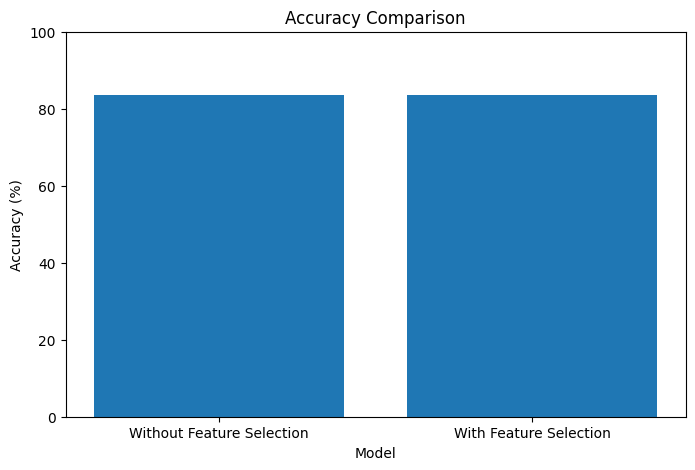

In [24]:
# ============================================
# ACCURACY COMPARISON GRAPH
# ============================================

models = [
    "Without Feature Selection",
    "With Feature Selection"
]

accuracies = [
    accuracy_all * 100,
    accuracy_selected * 100
]

plt.figure(figsize=(8, 5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Accuracy Comparison")

plt.ylim(0, 100)

plt.show()

In [25]:
# ============================================
# COMPLETE MODEL COMPARISON
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Without Feature Selection
accuracy_all = accuracy_score(y_test, y_pred_all)
precision_all = precision_score(y_test, y_pred_all)
recall_all = recall_score(y_test, y_pred_all)
f1_all = f1_score(y_test, y_pred_all)

# With Feature Selection
accuracy_selected = accuracy_score(y_test, y_pred_selected)
precision_selected = precision_score(y_test, y_pred_selected)
recall_selected = recall_score(y_test, y_pred_selected)
f1_selected = f1_score(y_test, y_pred_selected)

print("==============================================")
print("       MODEL PERFORMANCE COMPARISON")
print("==============================================")

print("\nWITHOUT FEATURE SELECTION")
print("----------------------------------------------")
print("Accuracy :", round(accuracy_all * 100, 2), "%")
print("Precision:", round(precision_all * 100, 2), "%")
print("Recall   :", round(recall_all * 100, 2), "%")
print("F1 Score :", round(f1_all * 100, 2), "%")

print("\nWITH FEATURE SELECTION")
print("----------------------------------------------")
print("Accuracy :", round(accuracy_selected * 100, 2), "%")
print("Precision:", round(precision_selected * 100, 2), "%")
print("Recall   :", round(recall_selected * 100, 2), "%")
print("F1 Score :", round(f1_selected * 100, 2), "%")

       MODEL PERFORMANCE COMPARISON

WITHOUT FEATURE SELECTION
----------------------------------------------
Accuracy : 83.61 %
Precision: 84.85 %
Recall   : 84.85 %
F1 Score : 84.85 %

WITH FEATURE SELECTION
----------------------------------------------
Accuracy : 83.61 %
Precision: 84.85 %
Recall   : 84.85 %
F1 Score : 84.85 %


In [26]:
import joblib

# Save the trained model
joblib.dump(model, "heart_disease_model.pkl")

# Save feature selector
joblib.dump(selector, "feature_selector.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

print("Model, feature selector and scaler saved successfully!")

Model, feature selector and scaler saved successfully!


In [27]:
from google.colab import files

files.download("heart_disease_model.pkl")
files.download("feature_selector.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
# ============================================
# FINAL PROJECT SUMMARY
# ============================================

print("=" * 55)
print("       DISEASE RISK PREDICTION PROJECT")
print("=" * 55)

print("\nDataset Information")
print("-" * 55)
print("Total records       :", len(df))
print("Original features   :", 22)
print("Selected features   :", 8)
print("Training samples    :", len(X_train))
print("Testing samples     :", len(X_test))

print("\nSelected Features")
print("-" * 55)
for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

print("\nModel")
print("-" * 55)
print("Algorithm           : Logistic Regression")
print("Feature Selection   : SelectKBest (ANOVA F-test)")
print("Feature Scaling     : StandardScaler")

print("\nModel Performance")
print("-" * 55)
print("Accuracy            :", round(accuracy_selected * 100, 2), "%")
print("Precision           :", round(precision_selected * 100, 2), "%")
print("Recall              :", round(recall_selected * 100, 2), "%")
print("F1 Score            :", round(f1_selected * 100, 2), "%")

print("\nFeature Selection Comparison")
print("-" * 55)
print("Before Selection    : 22 features")
print("After Selection     : 8 features")
print("Accuracy Before     :", round(accuracy_all * 100, 2), "%")
print("Accuracy After      :", round(accuracy_selected * 100, 2), "%")

print("\n" + "=" * 55)
print("              PROJECT COMPLETED")
print("=" * 55)

       DISEASE RISK PREDICTION PROJECT

Dataset Information
-------------------------------------------------------
Total records       : 302
Original features   : 22
Selected features   : 8
Training samples    : 241
Testing samples     : 61

Selected Features
-------------------------------------------------------
1. Max_heart_rate
2. oldpeak
3. chest_pain_type_Non-anginal pain
4. chest_pain_type_Typical angina
5. exercise_induced_angina_Yes
6. slope_Flat
7. vessels_colored_by_flourosopy_Zero
8. thalassemia_Reversable Defect

Model
-------------------------------------------------------
Algorithm           : Logistic Regression
Feature Selection   : SelectKBest (ANOVA F-test)
Feature Scaling     : StandardScaler

Model Performance
-------------------------------------------------------
Accuracy            : 83.61 %
Precision           : 84.85 %
Recall              : 84.85 %
F1 Score            : 84.85 %

Feature Selection Comparison
----------------------------------------------------